In [ ]:
# 결측치: median으로 한 줄 컷
df['col'] = df['col'].fillna(df['col'].median()) #median에 다른 집계함수 가능

#수치형 변수들의 이상치 리스트
num_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# 데이터프레임 전체에 바로 적용
df[num_cols] = df[num_cols].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR, axis=1)

In [ ]:
import pandas as pd
import numpy as np

# 재현성을 위한 시드 설정
np.random.seed(42)

# 일부 결측값과 잠재적 이상치가 있는 샘플 DataFrame 생성
data = {
    'numerical_col_1': np.random.rand(100) * 100,
    'numerical_col_2': np.random.normal(50, 15, 100),
    'categorical_col': np.random.choice(['A', 'B', 'C', 'D'], 100)
}
df = pd.DataFrame(data)

# 무작위로 결측값 추가
for col in df.columns:
    missing_indices = np.random.choice(df.index, size=np.random.randint(5, 15), replace=False)
    df.loc[missing_indices, col] = np.nan

# numerical_col_1과 numerical_col_2에 이상치 추가
df.loc[0, 'numerical_col_1'] = 1000 # 이상치
df.loc[10, 'numerical_col_2'] = -50 # 이상치
df.loc[20, 'numerical_col_1'] = -200 # 이상치
df.loc[30, 'numerical_col_2'] = 500 # 이상치

display(df.head())
print(df.info())

,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,NaN,45.514890,NaN
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   numerical_col_1  93 non-null     float64
 1   numerical_col_2  95 non-null     float64
 2   categorical_col  91 non-null     object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB
None


### 1. 결측치 처리

#### 1.1 결측치 확인

먼저 데이터프레임 내 결측치가 있는지 확인합니다. `isnull().sum()` 메서드를 사용하여 각 열의 결측치 개수를 확인할 수 있습니다.

In [ ]:
print('각 컬럼별 결측치 개수:')
display(df.isnull().sum())

print('\n결측치가 있는 행 확인 (상위 5개):')
display(df[df.isnull().any(axis=1)].head())

각 컬럼별 결측치 개수:


,0
numerical_col_1,7
numerical_col_2,5
categorical_col,9



결측치가 있는 행 확인 (상위 5개):


,numerical_col_1,numerical_col_2,categorical_col
1,NaN,45.514890,NaN
5,15.599452,NaN,C
10,NaN,-50.000000,A
11,96.990985,54.931267,NaN
14,18.182497,NaN,C


#### 1.2 결측치 대치 (Imputation)

결측치를 처리하는 다양한 방법이 있습니다. 데이터의 특성과 분석 목표에 따라 적절한 방법을 선택해야 합니다.

##### 1.2.1 상수(Constant)로 대치

결측치를 특정 상수로 채웁니다. 예를 들어 0 또는 '-1'과 같은 값을 사용할 수 있습니다. `fillna()` 메서드를 사용합니다.

In [ ]:
df_constant = df.copy()
# numerical_col_1의 결측치를 0으로 대치
df_constant['numerical_col_1'] = df_constant['numerical_col_1'].fillna(0)
# categorical_col의 결측치를 'Unknown'으로 대치
df_constant['categorical_col'] = df_constant['categorical_col'].fillna('Unknown')

print('상수 대치 후 결측치 개수:')
display(df_constant.isnull().sum())
display(df_constant.head())

상수 대치 후 결측치 개수:


,0
numerical_col_1,0
numerical_col_2,5
categorical_col,0


,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,0.000000,45.514890,Unknown
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


##### 1.2.2 평균값(Mean)으로 대치

수치형 데이터의 결측치를 해당 열의 평균값으로 대치합니다. 이는 데이터의 분포를 크게 왜곡하지 않으면서 결측치를 처리할 수 있는 일반적인 방법입니다.

##### 1.2.9 SimpleImputer를 이용한 대치

`sklearn.impute.SimpleImputer`는 평균(mean), 중앙값(median), 최빈값(most_frequent) 또는 특정 상수(constant)와 같은 대푯값을 사용하여 결측치를 대치하는 유연한 방법을 제공합니다. 특히 파이프라인 구성 시 편리하게 사용할 수 있습니다.

In [ ]:
from sklearn.impute import SimpleImputer

df_simple_imputer = df.copy()

# 수치형 컬럼의 결측치를 평균으로 대치
mean_imputer = SimpleImputer(strategy='mean')
df_simple_imputer[['numerical_col_1', 'numerical_col_2']] = mean_imputer.fit_transform(df_simple_imputer[['numerical_col_1', 'numerical_col_2']])

# 범주형 컬럼의 결측치를 최빈값으로 대치
mode_imputer = SimpleImputer(strategy='most_frequent')
df_simple_imputer[['categorical_col']] = mode_imputer.fit_transform(df_simple_imputer[['categorical_col']])

print('SimpleImputer 대치 후 결측치 개수:')
display(df_simple_imputer.isnull().sum())
display(df_simple_imputer.head())

SimpleImputer 대치 후 결측치 개수:


,0
numerical_col_1,0
numerical_col_2,0
categorical_col,0


,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,53.932976,45.514890,A
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


In [ ]:
df_mean = df.copy()
mean_numerical_col_1 = df_mean['numerical_col_1'].mean()
mean_numerical_col_2 = df_mean['numerical_col_2'].mean()

df_mean['numerical_col_1'] = df_mean['numerical_col_1'].fillna(mean_numerical_col_1)
df_mean['numerical_col_2'] = df_mean['numerical_col_2'].fillna(mean_numerical_col_2)

print('평균값 대치 후 결측치 개수:')
display(df_mean.isnull().sum())
display(df_mean.head())

평균값 대치 후 결측치 개수:


,0
numerical_col_1,0
numerical_col_2,0
categorical_col,9


,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,53.932976,45.514890,NaN
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


##### 1.2.3 중앙값(Median)으로 대치

수치형 데이터의 결측치를 해당 열의 중앙값으로 대치합니다. 평균값과 달리 이상치의 영향을 덜 받는다는 장점이 있습니다.

In [ ]:
df_median = df.copy()
median_numerical_col_1 = df_median['numerical_col_1'].median()
median_numerical_col_2 = df_median['numerical_col_2'].median()

df_median['numerical_col_1'] = df_median['numerical_col_1'].fillna(median_numerical_col_1)
df_median['numerical_col_2'] = df_median['numerical_col_2'].fillna(median_numerical_col_2)

print('중앙값 대치 후 결측치 개수:')
display(df_median.isnull().sum())
display(df_median.head())

중앙값 대치 후 결측치 개수:


,0
numerical_col_1,0
numerical_col_2,0
categorical_col,9


,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,44.015249,45.514890,NaN
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


##### 1.2.4 최빈값(Mode)으로 대치

범주형 데이터의 결측치를 해당 열의 최빈값으로 대치합니다. 수치형 데이터에도 적용할 수 있지만, 주로 범주형 데이터에 사용됩니다.

In [ ]:
df_mode = df.copy()

# numerical_col_1의 최빈값으로 대치
mode_numerical_col_1 = df_mode['numerical_col_1'].mode()[0]
df_mode['numerical_col_1'] = df_mode['numerical_col_1'].fillna(mode_numerical_col_1)

# categorical_col의 최빈값으로 대치
mode_categorical_col = df_mode['categorical_col'].mode()[0]
df_mode['categorical_col'] = df_mode['categorical_col'].fillna(mode_categorical_col)

print('최빈값 대치 후 결측치 개수:')
display(df_mode.isnull().sum())
display(df_mode.head())

최빈값 대치 후 결측치 개수:


,0
numerical_col_1,0
numerical_col_2,5
categorical_col,0


,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,-200.000000,45.514890,A
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


##### 1.2.5 단순 확률 대치 (Simple Probabilistic Imputation)

결측치를 해당 열의 기존 값들의 분포를 기반으로 무작위로 선택하여 대치하는 방법입니다. 범주형 데이터에 특히 유용하며, 결측치가 있는 데이터를 삭제하지 않고도 데이터의 통계적 특성을 유지하는 데 도움이 될 수 있습니다.

In [ ]:
# 1. 결측치가 있는 인덱스 추출
idx = df_probabilistic[df_probabilistic['categorical_col'].isnull()].index

# 2. 결측치 개수만큼 비결측치에서 샘플링하여 방에 대입
if len(idx) > 0:
    df_probabilistic.loc[idx, 'categorical_col'] = \
    df_probabilistic['categorical_col'].dropna().sample(len(idx), replace=True).values
    #.values를 넣어야 값이 순서대로 넘어감
# 결과 확인
print(df_probabilistic['categorical_col'].isnull().sum())
display(df_probabilistic.head())

0


,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,NaN,45.514890,B
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


##### 1.2.6 kNN(k-Nearest Neighbors) 대치

kNN 대치는 결측치가 있는 샘플과 가장 유사한(k개의) 이웃 샘플들의 값을 기반으로 결측치를 대치합니다. `sklearn.impute.KNNImputer`를 사용합니다.

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

df_knn = df.copy()

# kNN Imputer는 수치형 데이터에 작동하므로 범주형 데이터를 인코딩해야 합니다.
# 여기서는 'categorical_col'만 해당되므로 Label Encoding을 사용합니다.
le = LabelEncoder()
df_knn['categorical_col_encoded'] = le.fit_transform(df_knn['categorical_col'])

# 원본 범주형 컬럼은 drop하거나 나중에 처리합니다.
df_knn_numerical = df_knn[['numerical_col_1', 'numerical_col_2', 'categorical_col_encoded']]

imputer = KNNImputer(n_neighbors=5)
df_knn_imputed_array = imputer.fit_transform(df_knn_numerical)

df_knn_imputed = pd.DataFrame(df_knn_imputed_array, columns=df_knn_numerical.columns)

# 인코딩된 범주형 컬럼을 다시 원본 형태로 디코딩 (필요하다면)
# kNN Imputer는 연속적인 값을 출력할 수 있으므로, 반올림 후 디코딩해야 합니다.
df_knn_imputed['categorical_col_decoded'] = le.inverse_transform(np.round(df_knn_imputed['categorical_col_encoded']).astype(int))

print('kNN 대치 후 결측치 개수 (원래 컬럼 기준):')
# 원본 df에 다시 반영하여 확인
df_knn['numerical_col_1'] = df_knn_imputed['numerical_col_1']
df_knn['numerical_col_2'] = df_knn_imputed['numerical_col_2']
df_knn['categorical_col'] = df_knn_imputed['categorical_col_decoded'] # 디코딩된 값 사용

display(df_knn.isnull().sum())
display(df_knn.head())

kNN 대치 후 결측치 개수 (원래 컬럼 기준):


,0
numerical_col_1,0
numerical_col_2,0
categorical_col,9
categorical_col_encoded,0


,numerical_col_1,numerical_col_2,categorical_col,categorical_col_encoded
0,1000.000000,51.305706,B,1
1,31.076223,45.514890,NaN,4
2,73.199394,51.376412,B,1
3,59.865848,20.186466,A,0
4,15.601864,46.704922,D,3


##### 1.2.7 회귀 및 분류 알고리즘 대치 (Regression and Classification Algorithm Imputation)

결측치가 있는 열을 종속 변수로, 다른 열들을 독립 변수로 사용하여 예측 모델을 구축하고 결측치를 예측값으로 채우는 방법입니다. 수치형 데이터에는 회귀 모델을, 범주형 데이터에는 분류 모델을 사용할 수 있습니다. 이는 더 정교한 대치 방법이지만, 구현이 복잡하고 모델 선택에 따라 성능이 달라질 수 있습니다.

**예시 (개념 설명):**

*   `numerical_col_1`에 결측치가 있다면, `numerical_col_2`와 `categorical_col`을 사용하여 `numerical_col_1`의 값을 예측하는 회귀 모델(예: `LinearRegression`, `RandomForestRegressor`)을 훈련시킵니다. 그리고 결측치를 이 모델의 예측값으로 채웁니다.
*   `categorical_col`에 결측치가 있다면, `numerical_col_1`과 `numerical_col_2`를 사용하여 `categorical_col`의 값을 예측하는 분류 모델(예: `LogisticRegression`, `RandomForestClassifier`)을 훈련시킵니다. 그리고 결측치를 이 모델의 예측값으로 채웁니다.

이 방법은 `IterativeImputer` (MICE - Multiple Imputation by Chained Equations)를 사용하여 구현할 수 있습니다.

In [ ]:
from sklearn.experimental import enable_iterative_imputer # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

df_iterative = df.copy()

# 범주형 데이터를 수치형으로 인코딩 (IterativeImputer는 수치형 데이터에 작동)
le = LabelEncoder()
df_iterative['categorical_col_encoded'] = le.fit_transform(df_iterative['categorical_col'])

# IterativeImputer를 위한 데이터 준비
df_iterative_cols = df_iterative[['numerical_col_1', 'numerical_col_2', 'categorical_col_encoded']]

# 회귀 모델로 RandomForestRegressor를 사용 (default는 BayesianRidge)
imputer = IterativeImputer(RandomForestRegressor(), max_iter=10, random_state=42)

df_iterative_imputed_array = imputer.fit_transform(df_iterative_cols)

df_iterative_imputed = pd.DataFrame(df_iterative_imputed_array, columns=df_iterative_cols.columns)

# 인코딩된 범주형 컬럼을 다시 디코딩
df_iterative_imputed['categorical_col_decoded'] = le.inverse_transform(np.round(df_iterative_imputed['categorical_col_encoded']).astype(int))

# 원본 df에 다시 반영
df_iterative['numerical_col_1'] = df_iterative_imputed['numerical_col_1']
df_iterative['numerical_col_2'] = df_iterative_imputed['numerical_col_2']
df_iterative['categorical_col'] = df_iterative_imputed['categorical_col_decoded']

print('회귀/분류 알고리즘 대치 (IterativeImputer) 후 결측치 개수:')
display(df_iterative.isnull().sum())
display(df_iterative.head())

회귀/분류 알고리즘 대치 (IterativeImputer) 후 결측치 개수:


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,0
numerical_col_1,0
numerical_col_2,0
categorical_col,9
categorical_col_encoded,0


,numerical_col_1,numerical_col_2,categorical_col,categorical_col_encoded
0,1000.000000,51.305706,B,1
1,62.908758,45.514890,NaN,4
2,73.199394,51.376412,B,1
3,59.865848,20.186466,A,0
4,15.601864,46.704922,D,3


#### 1.3. 보간법 (Interpolation)

보간법은 알려진 데이터 포인트 사이의 결측값을 추정하는 방법입니다. 시계열 데이터에 특히 유용하며, `interpolate()` 메서드를 사용합니다.

*   **선형(Linear) 보간법**: 가장 간단한 형태로, 인접한 두 점 사이를 직선으로 연결하여 결측값을 추정합니다.
*   **다항식(Polynomial) 보간법**: 인접한 점들 사이에 다항식을 맞춰 결측값을 추정합니다. 데이터의 곡선 형태를 반영할 수 있습니다.
*   **스플라인(Spline) 보간법**: 부드러운 곡선을 사용하여 결측값을 추정합니다. 다항식 보간법보다 더 유연하고 부드러운 결과를 제공합니다.

In [ ]:
df_interp_linear = df.copy()
# numerical_col_1에 선형 보간법 적용
df_interp_linear['numerical_col_1'] = df_interp_linear['numerical_col_1'].interpolate(method='linear')

print('선형 보간법 적용 후 결측치 개수:')
display(df_interp_linear.isnull().sum())
display(df_interp_linear.head())

선형 보간법 적용 후 결측치 개수:


,0
numerical_col_1,0
numerical_col_2,5
categorical_col,9


,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,536.599697,45.514890,NaN
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


In [ ]:
df_interp_polynomial = df.copy()
# numerical_col_2에 다항식 보간법 적용 (order=2)
df_interp_polynomial['numerical_col_2'] = df_interp_polynomial['numerical_col_2'] \
                                            .interpolate(method='polynomial', order=2)

print('다항식 보간법 적용 후 결측치 개수:')
display(df_interp_polynomial.isnull().sum())
display(df_interp_polynomial.head())

다항식 보간법 적용 후 결측치 개수:


,0
numerical_col_1,7
numerical_col_2,1
categorical_col,9


,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,NaN,45.514890,NaN
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


In [ ]:
df_interp_spline = df.copy()
# numerical_col_1에 스플라인 보간법 적용 (order=3)
df_interp_spline['numerical_col_1'] = df_interp_spline['numerical_col_1'] \
                                        .interpolate(method='spline', order=3)

print('스플라인 보간법 적용 후 결측치 개수:')
display(df_interp_spline.isnull().sum())
display(df_interp_spline.head())

스플라인 보간법 적용 후 결측치 개수:


,0
numerical_col_1,0
numerical_col_2,5
categorical_col,9


,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,280.791662,45.514890,NaN
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


### 2. 이상치 처리 (Outlier Handling)

이상치(Outlier)는 데이터 분포에서 크게 벗어난 값으로, 모델 성능에 부정적인 영향을 줄 수 있습니다. 이상치를 처리하는 다양한 방법이 있습니다.

먼저 `numerical_col_1` 컬럼을 예시로 이상치를 시각적으로 확인해보겠습니다.

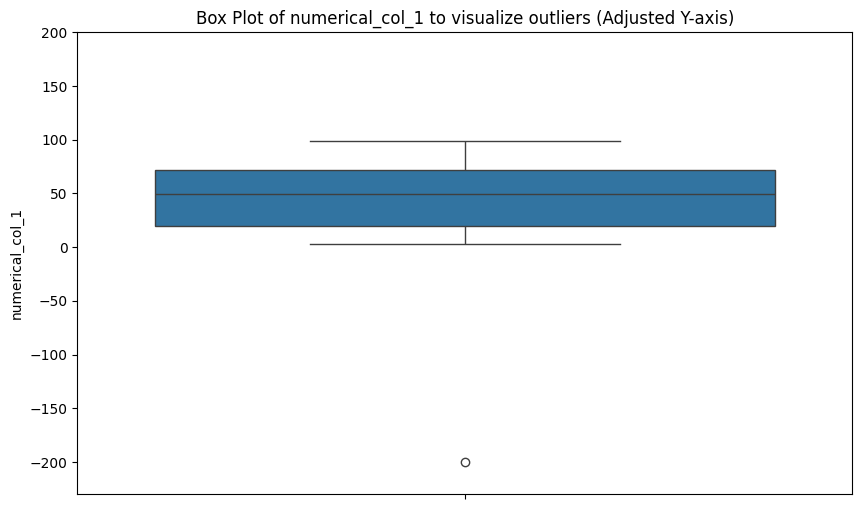

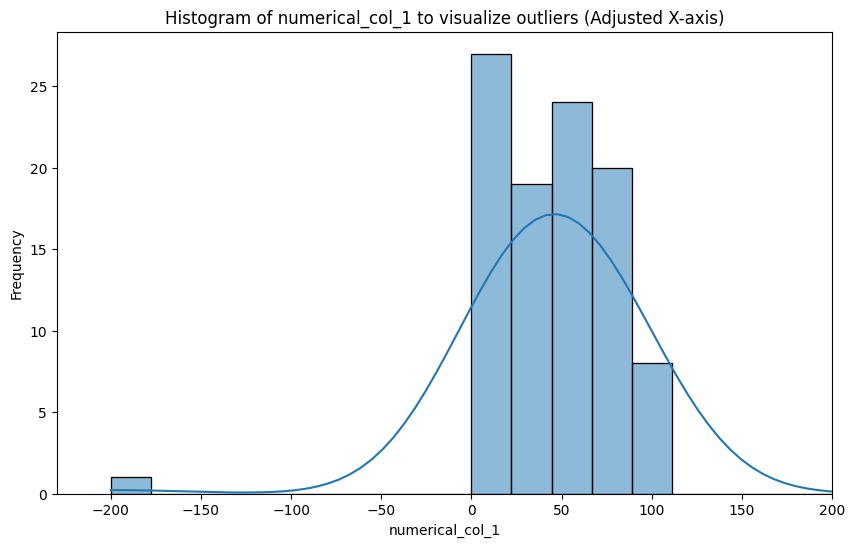

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 결측치가 없는 데이터프레임 복사 (이상치 처리는 결측치가 없는 상태에서 진행하는 것이 일반적)
df_cleaned_for_outliers = df.fillna(df.mean(numeric_only=True))

# IQR 기반의 하한/상한 값 (이전 셀에서 계산된 값 활용)
Q1_viz = df_cleaned_for_outliers['numerical_col_1'].quantile(0.25)
Q3_viz = df_cleaned_for_outliers['numerical_col_1'].quantile(0.75)
IQR_viz = Q3_viz - Q1_viz
lower_bound_viz = Q1_viz - 1.5 * IQR_viz
upper_bound_viz = Q3_viz + 1.5 * IQR_viz

plt.figure(figsize=(10, 6))
sns.boxplot(y=df_cleaned_for_outliers['numerical_col_1'])
plt.title('Box Plot of numerical_col_1 to visualize outliers (Adjusted Y-axis)')
plt.ylabel('numerical_col_1')
plt.ylim(y_min_display, y_max_display) # Y축 범위 설정
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned_for_outliers['numerical_col_1'], kde=True)
plt.title('Histogram of numerical_col_1 to visualize outliers (Adjusted X-axis)')
plt.xlabel('numerical_col_1')
plt.ylabel('Frequency')
plt.xlim(y_min_display, y_max_display) # 히스토그램의 경우 x축 범위 설정
plt.show()

#### 2.1 이상치 감지

이상치를 처리하기 전에 먼저 이상치를 감지 방법
#####IQR (Interquartile Range) 방법

데이터 분포에서 크게 벗어난 값을 통계적으로 정의
*   Q1 (1사분위수): 데이터의 하위 25%
*   Q3 (3사분위수): 데이터의 상위 25%
*   IQR = Q3 - Q1
*   하한(Lower Bound): Q1 - 1.5 * IQR
*   상한(Upper Bound): Q3 + 1.5 * IQR
이 범위를 벗어나는 데이터 포인트는 이상치로 간주

#####ESD (Extreme Studentized Deviate) 방법
데이터가 정규 분포를 따른다는 가정 하에, 가장 극단적인 데이터 포인트가 이상치인지 여부를 통계적으로 테스트. 여러 개의 이상치를 순차적으로 감지

#####기하평균(Geometric Mean)을 이용한 이상치 감지
데이터 분포가 skewed되어 있을 때 유용. 특히 양의 값으로 구성된 데이터에서 큰 값의 이상치를 감지하는 데 활용

#####DBSCAN을 통한 이상치 판단
DBSCAN(Density-Based Spatial Clustering of Applications with Noise)은 군집 기반 이상치 감지 방법. 데이터 포인트들을 밀도에 따라 군집화하고, 어떤 군집에도 속하지 않는 데이터 포인트를 노이즈(이상치)로 간주.

DBSCAN으로 감지된 이상치 개수: 4

DBSCAN으로 감지된 이상치:


,numerical_col_1,numerical_col_2
0,1000.000000,51.305706
10,53.932976,-50.000000
20,-200.000000,54.441804
30,60.754485,500.000000


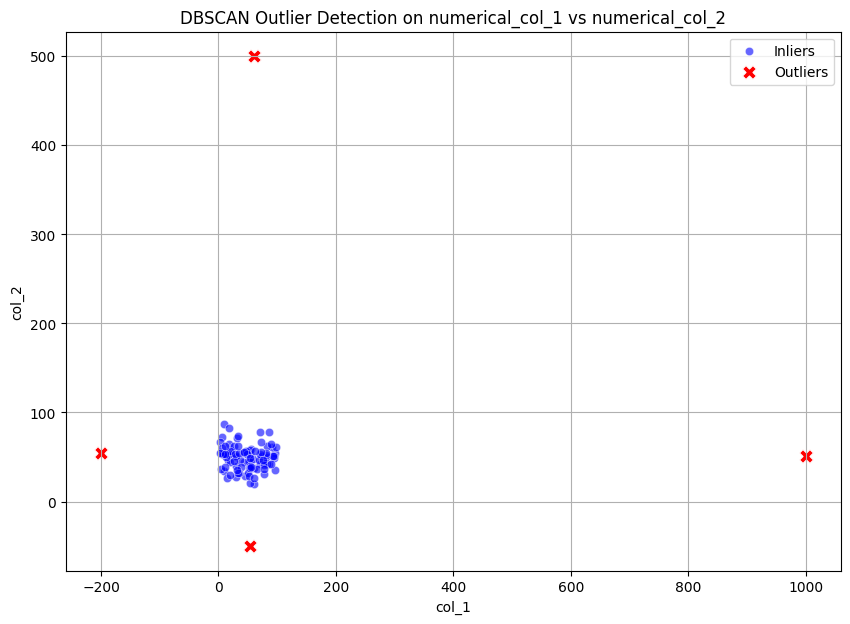

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# DBSCAN은 스케일링된 데이터에서 더 잘 작동합니다.
# 이상치 처리 전 결측치가 없는 df_cleaned_for_outliers 사용
df_dbscan = df_cleaned_for_outliers[['numerical_col_1', 'numerical_col_2']].copy()

# 데이터 스케일링
scaler = StandardScaler()
df_dbscan_scaled = scaler.fit_transform(df_dbscan)

# DBSCAN 모델 정의 및 적용
# eps: 이웃으로 간주할 최대 거리, min_samples: 코어 포인트가 되기 위한 최소 샘플 수
# 이 파라미터들은 데이터에 따라 조정이 필요할 수 있습니다.
db = DBSCAN(eps=0.5, min_samples=5).fit(df_dbscan_scaled)
labels = db.labels_

# -1로 레이블링된 포인트는 이상치로 간주됩니다.
outliers_dbscan = df_dbscan[labels == -1]
inliers_dbscan = df_dbscan[labels != -1]

print(f'DBSCAN으로 감지된 이상치 개수: {len(outliers_dbscan)}')
print('\nDBSCAN으로 감지된 이상치:')
display(outliers_dbscan.head())

# 시각화
plt.figure(figsize=(10, 7))
sns.scatterplot(x=inliers_dbscan['numerical_col_1'], y=inliers_dbscan['numerical_col_2'], color='blue', label='Inliers', alpha=0.6)
sns.scatterplot(x=outliers_dbscan['numerical_col_1'], y=outliers_dbscan['numerical_col_2'], color='red', label='Outliers', marker='X', s=100)
plt.title('DBSCAN Outlier Detection on numerical_col_1 vs numerical_col_2')
plt.xlabel('col_1')
plt.ylabel('col_2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
Q1 = df_cleaned_for_outliers['numerical_col_1'].quantile(0.25)
Q3 = df_cleaned_for_outliers['numerical_col_1'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1:.2f}')
print(f'Q3: {Q3:.2f}')
print(f'IQR: {IQR:.2f}')
print(f'Lower Bound: {lower_bound:.2f}')
print(f'Upper Bound: {upper_bound:.2f}')

outliers = df_cleaned_for_outliers[
    (df_cleaned_for_outliers['numerical_col_1'] < lower_bound) |
    (df_cleaned_for_outliers['numerical_col_1'] > upper_bound)
]

print('\n감지된 이상치 (numerical_col_1):')
display(outliers[['numerical_col_1']])

Q1: 19.80
Q3: 71.72
IQR: 51.92
Lower Bound: -58.07
Upper Bound: 149.59

감지된 이상치 (numerical_col_1):


,numerical_col_1
0,1000.0
20,-200.0


#### 2.2 이상치 절단 (Outlier Trimming/Removal)

이상치로 판단된 데이터 포인트를 제거하는 가장 간단한 방법입니다. 데이터 손실이 발생할 수 있으므로 주의해서 사용해야 합니다.

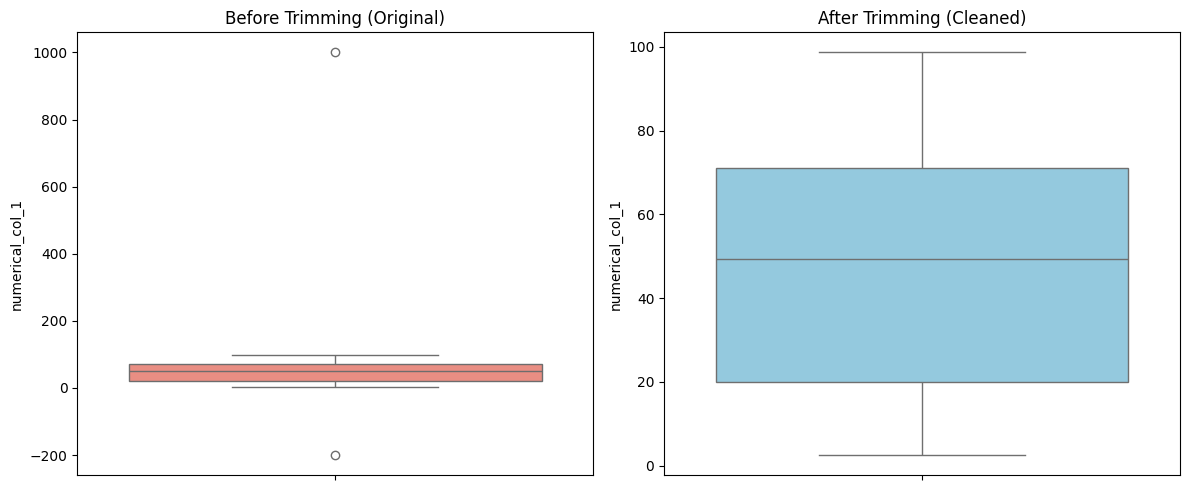

제거된 이상치 개수: 2
최종 데이터 개수: 98


In [ ]:
# 1. 제거할 대상의 인덱스 추출
outlier_idx = df_cleaned_for_outliers[
    (df_cleaned_for_outliers['numerical_col_1'] < lower_bound) |
    (df_cleaned_for_outliers['numerical_col_1'] > upper_bound)
].index

# 2. .drop()으로 이상치 제거
df_trimmed = df_cleaned_for_outliers.drop(outlier_idx).copy()

# 3. 전후 시각화 (Boxplot)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_cleaned_for_outliers['numerical_col_1'], ax=axes[0], color='salmon')
axes[0].set_title('Before Trimming (Original)')

sns.boxplot(y=df_trimmed['numerical_col_1'], ax=axes[1], color='skyblue')
axes[1].set_title('After Trimming (Cleaned)')

plt.tight_layout()
plt.show()

print(f'제거된 이상치 개수: {len(outlier_idx)}')
print(f'최종 데이터 개수: {len(df_trimmed)}')

#### 2.3 이상치 조정/윈저라이징 (Outlier Adjustment/Winsorization)

이상치를 제거하는 대신, 이상치를 특정 상한 또는 하한 값으로 대체하여 데이터 손실을 줄이는 방법입니다. 이상치의 영향을 줄이면서 데이터의 크기를 보존할 수 있습니다.

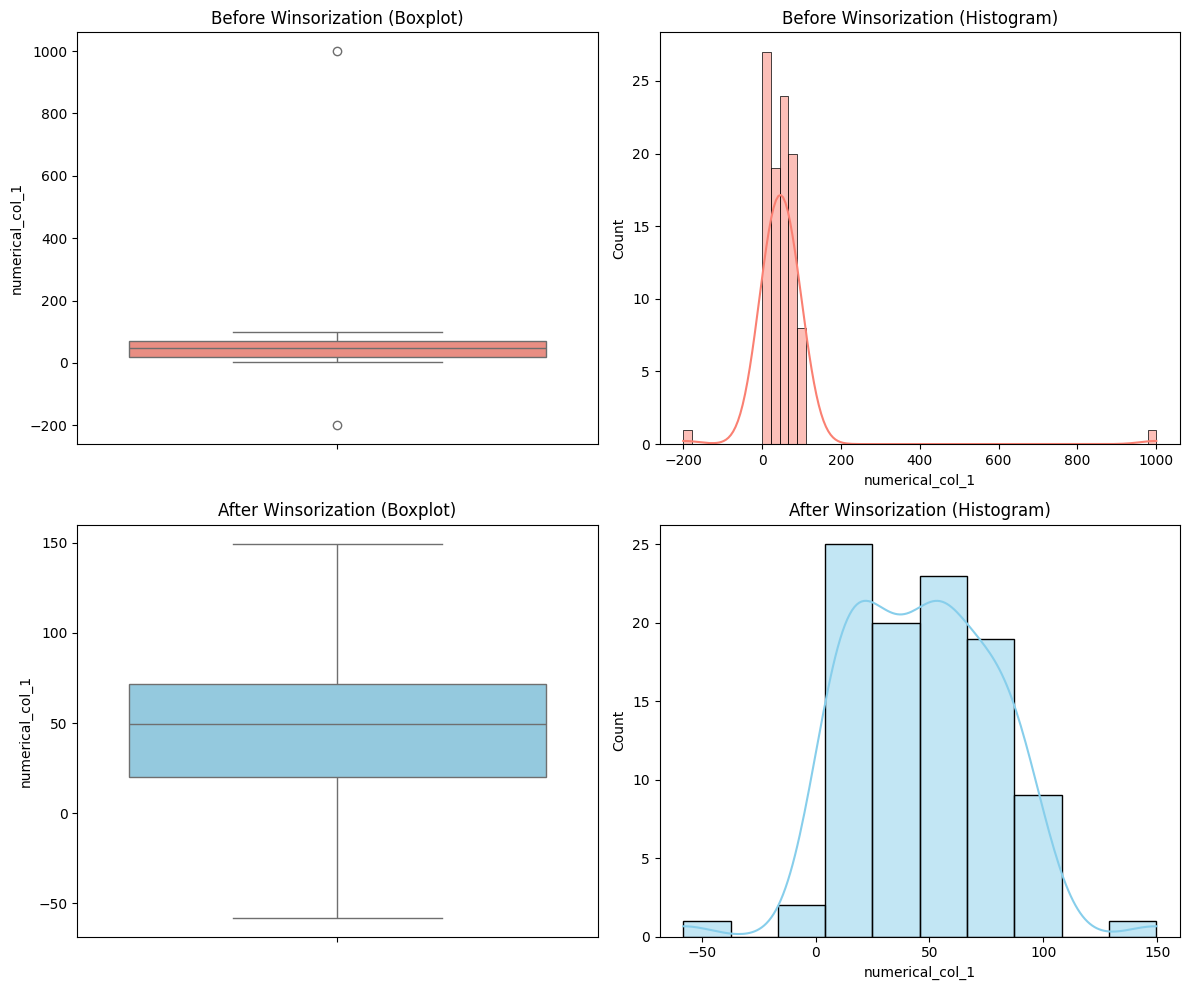

조정된 이상치 값 확인:


,numerical_col_1
0,149.591474
20,-58.069688


In [ ]:
# 1. .clip()을 사용하여 하한선(lower)과 상한선(upper)으로 한 방에 고정
df_winsorized = df_cleaned_for_outliers.copy()
df_winsorized['numerical_col_1'] = df_winsorized['numerical_col_1'].clip(lower_bound, upper_bound)

# 2. 전후 시각화 (Boxplot & Histogram)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# [Before] 시각화
sns.boxplot(y=df_cleaned_for_outliers['numerical_col_1'], ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Before Winsorization (Boxplot)')
sns.histplot(df_cleaned_for_outliers['numerical_col_1'], ax=axes[0, 1], color='salmon', kde=True)
axes[0, 1].set_title('Before Winsorization (Histogram)')

# [After] 시각화
sns.boxplot(y=df_winsorized['numerical_col_1'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('After Winsorization (Boxplot)')
sns.histplot(df_winsorized['numerical_col_1'], ax=axes[1, 1], color='skyblue', kde=True)
axes[1, 1].set_title('After Winsorization (Histogram)')

plt.tight_layout()
plt.show()

# 3. 변경된 값 확인 (기존 이상치 인덱스 기준)
print('조정된 이상치 값 확인:')
display(df_winsorized.loc[outlier_idx, ['numerical_col_1']])

#### 2.4 이상치 클리핑 (Outlier Clipping)

클리핑은 이상치를 특정 범위 내의 최댓값 또는 최솟값으로 제한하는 방법입니다. 윈저라이징과 유사하지만, 보통 특정 백분위수(예: 1% 또는 99%)를 기준으로 값을 제한합니다. `clip()` 메서드를 사용할 수 있습니다.

In [ ]:
df_clipped = df_cleaned_for_outliers.copy()

# 1%와 99% 백분위수를 기준으로 클리핑
lower_percentile = df_clipped['numerical_col_1'].quantile(0.01)
upper_percentile = df_clipped['numerical_col_1'].quantile(0.99)

df_clipped['numerical_col_1'] = df_clipped['numerical_col_1'].clip(lower=lower_percentile, upper=upper_percentile)

print(f'1% 백분위수: {lower_percentile:.2f}')
print(f'99% 백분위수: {upper_percentile:.2f}')
print('\n이상치 클리핑 후 데이터 (numerical_col_1 컬럼):')
# 변경된 이상치 값 확인 (클리핑 전후 비교를 위해 원본 이상치 인덱스 사용)
outliers_before_clipping = df_cleaned_for_outliers[
    (df_cleaned_for_outliers['numerical_col_1'] < lower_percentile) |
    (df_cleaned_for_outliers['numerical_col_1'] > upper_percentile)
]
display(df_clipped.loc[outliers_before_clipping.index][['numerical_col_1']])
display(df_clipped.head())

1% 백분위수: 0.52
99% 백분위수: 107.70

이상치 클리핑 후 데이터 (numerical_col_1 컬럼):


,numerical_col_1
0,107.701807
20,0.516494


,numerical_col_1,numerical_col_2,categorical_col
0,107.701807,51.305706,B
1,53.932976,45.514890,NaN
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


### 3. 결측치 처리 전후 비교

In [ ]:
print("--- 결측치 처리 전후 DataFrame Shape 비교 ---")
print(f"원본 df shape: {df.shape}")
print(f"SimpleImputer 적용 df_simple_imputer shape: {df_simple_imputer.shape}")

print("\n--- 결측치 처리 전후 각 컬럼별 결측치 개수 비교 ---")
print("원본 df 결측치:\n")
display(df.isnull().sum())
print("\nSimpleImputer 적용 df_simple_imputer 결측치:\n")
display(df_simple_imputer.isnull().sum())

print("\n--- 결측치 처리 전후 DataFrame head 비교 ---")
print("원본 df head:\n")
display(df.head())
print("\nSimpleImputer 적용 df_simple_imputer head:\n")
display(df_simple_imputer.head())

--- 결측치 처리 전후 DataFrame Shape 비교 ---
원본 df shape: (100, 3)
SimpleImputer 적용 df_simple_imputer shape: (100, 3)

--- 결측치 처리 전후 각 컬럼별 결측치 개수 비교 ---
원본 df 결측치:



,0
numerical_col_1,7
numerical_col_2,5
categorical_col,9



SimpleImputer 적용 df_simple_imputer 결측치:



,0
numerical_col_1,0
numerical_col_2,0
categorical_col,0



--- 결측치 처리 전후 DataFrame head 비교 ---
원본 df head:



,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,NaN,45.514890,NaN
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D



SimpleImputer 적용 df_simple_imputer head:



,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,53.932976,45.514890,A
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


### 4. 이상치 처리 전후 비교

--- 이상치 처리 전후 DataFrame Shape 비교 ---
이상치 처리 전 df_cleaned_for_outliers shape: (100, 3)
이상치 조정 후 df_winsorized shape: (100, 3)

--- 이상치 처리 전후 numerical_col_1 Boxplot 비교 ---


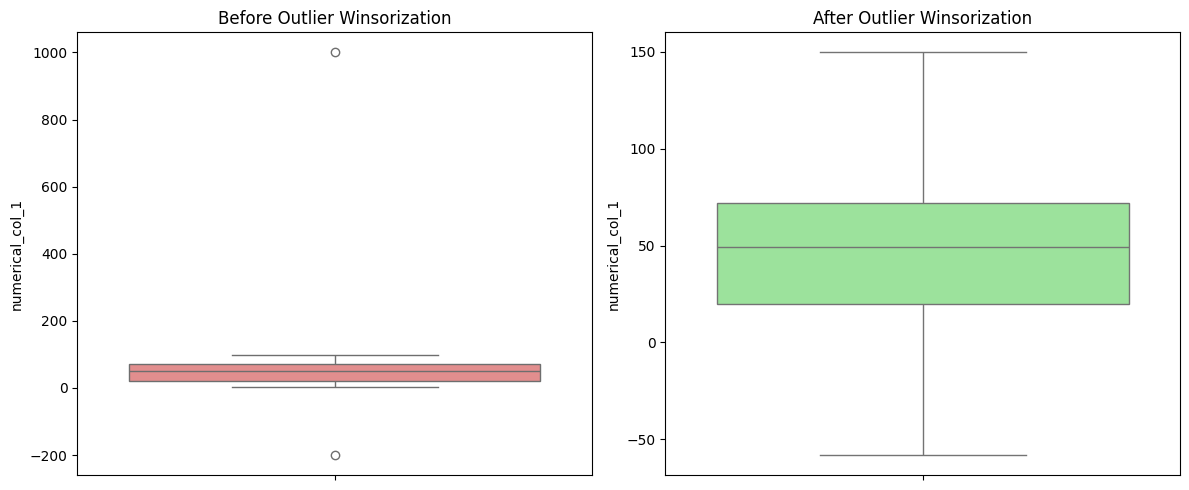


--- 이상치 처리 전후 DataFrame head 비교 ---
이상치 처리 전 df_cleaned_for_outliers head:



,numerical_col_1,numerical_col_2,categorical_col
0,1000.000000,51.305706,B
1,53.932976,45.514890,NaN
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D



이상치 조정 후 df_winsorized head:



,numerical_col_1,numerical_col_2,categorical_col
0,149.591474,51.305706,B
1,53.932976,45.514890,NaN
2,73.199394,51.376412,B
3,59.865848,20.186466,A
4,15.601864,46.704922,D


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 이상치 처리 전후 DataFrame Shape 비교 ---")
print(f"이상치 처리 전 df_cleaned_for_outliers shape: {df_cleaned_for_outliers.shape}")
print(f"이상치 조정 후 df_winsorized shape: {df_winsorized.shape}")

print("\n--- 이상치 처리 전후 numerical_col_1 Boxplot 비교 ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_cleaned_for_outliers['numerical_col_1'], ax=axes[0], color='lightcoral')
axes[0].set_title('Before Outlier Winsorization')
axes[0].set_ylabel('numerical_col_1')

sns.boxplot(y=df_winsorized['numerical_col_1'], ax=axes[1], color='lightgreen')
axes[1].set_title('After Outlier Winsorization')
axes[1].set_ylabel('numerical_col_1')

plt.tight_layout()
plt.show()

print("\n--- 이상치 처리 전후 DataFrame head 비교 ---")
print("이상치 처리 전 df_cleaned_for_outliers head:\n")
display(df_cleaned_for_outliers.head())
print("\n이상치 조정 후 df_winsorized head:\n")
display(df_winsorized.head())